# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

| Paso | Descripción |
|------|-------------|
| **1** | Carga de datos procesados y transformación de val con artefactos de train |
| **2** | Entrenamiento base + Fine-Tuning con GridSearchCV (4 modelos) |
| **3** | Diagnóstico overfitting/underfitting mediante Curvas de Aprendizaje |
| **4** | Conclusiones y validación del modelo con Test |

---
## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INTERIM_PATH   = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
MODELS_PATH    = PROJECT_ROOT / 'models'
FIGURES_DIR    = PROJECT_ROOT / 'reports' / 'figures'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
print(f'PROJECT_ROOT   : {PROJECT_ROOT}')
print(f'INTERIM_PATH   : {INTERIM_PATH}')
print(f'PROCESSED_PATH : {PROCESSED_PATH}')
print(f'MODELS_PATH    : {MODELS_PATH}')
print(f'FIGURES_DIR    : {FIGURES_DIR}')

PROJECT_ROOT   : C:\Proyecto\ds-ml-project-template
INTERIM_PATH   : C:\Proyecto\ds-ml-project-template\data\interim
PROCESSED_PATH : C:\Proyecto\ds-ml-project-template\data\processed
MODELS_PATH    : C:\Proyecto\ds-ml-project-template\models
FIGURES_DIR    : C:\Proyecto\ds-ml-project-template\reports\figures


---
## 1. Carga de Datos Procesados

In [2]:
TARGET  = 'median_house_value'
DROP    = ['latitude', 'longitude']

train   = pd.read_csv(PROCESSED_PATH / 'train_processed.csv')

X_train = train.drop(columns=[TARGET] + DROP)
y_train = train[TARGET]

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'\nFeatures: {list(X_train.columns)}')

X_train : (13209, 10)  |  y_train : (13209,)

Features: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


---
## 2. Entrenamiento Base y Fine-Tuning

Entrenamos los 4 modelos sobre `X_train` y los evaluamos sobre `X_val`.

Se reportan 4 métricas complementarias:

| Métrica | Por qué |
|---------|---------|
| **RMSE** | función de costo, en USD, penaliza errores grandes |
| **MAE** | robusta a outliers, error promedio absoluto en USD |
| **R²** | % de varianza explicada, independiente de escala |
| **Diferencia** | gap entre train y val — detecta overfitting |

`LinearRegression` no tiene hiperparámetros de regularización, por lo que se evalúa con **Ridge** (L2) para tener un término comparable con fine-tuning.  
El fine-tuning se realiza con **GridSearchCV (cv=5)** usando MSE como función de costo — es diferenciable y convexa, lo que garantiza una búsqueda de hiperparámetros coherente con el objetivo de optimización.

> ⚠️ **Nunca medir sobre el mismo conjunto de entrenamiento** — eso es sobreajuste garantizado.

In [3]:
import joblib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET = 'median_house_value'
DROP   = ['latitude', 'longitude']

# ─── Cargar artefactos ────────────────────────────────────────────────────────
imputer = joblib.load(MODELS_PATH / 'imputer.pkl')
encoder = joblib.load(MODELS_PATH / 'encoder.pkl')
scaler  = joblib.load(MODELS_PATH / 'scaler.pkl')

# ─── Construir X_val con los pkl de train ─────────────────────────────────────
val   = pd.read_csv(INTERIM_PATH / 'val_set.csv')
X_val = val.drop(columns=[TARGET])
y_val = val[TARGET]

num_cols                          = X_val.select_dtypes(include='number').columns
X_val[num_cols]                   = imputer.transform(X_val[num_cols])
X_val['ocean_proximity']          = encoder.transform(X_val[['ocean_proximity']])
X_val['rooms_per_household']      = X_val['total_rooms']    / X_val['households']
X_val['bedrooms_per_room']        = X_val['total_bedrooms'] / X_val['total_rooms']
X_val['population_per_household'] = X_val['population']     / X_val['households']
num_cols_scale                    = [c for c in X_val.columns if c not in ['latitude', 'longitude']]
X_val[num_cols_scale]             = scaler.transform(X_val[num_cols_scale])
X_val                             = X_val.drop(columns=DROP)

print(f'X_val listo: {X_val.shape}  |  NaN: {X_val.isnull().sum().sum()}')

X_val listo: (3303, 10)  |  NaN: 0


In [4]:
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar(name, model, X_tr, y_tr, X_v, y_v):
    y_pred_tr = model.predict(X_tr)
    y_pred_v  = model.predict(X_v)
    return {
        'Modelo'     : name,
        'RMSE Train' : np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        'RMSE Val'   : np.sqrt(mean_squared_error(y_v,  y_pred_v)),
        'MAE Val'    : mean_absolute_error(y_v, y_pred_v),
        'R² Val'     : r2_score(y_v, y_pred_v),
        'Diferencia' : np.sqrt(mean_squared_error(y_v, y_pred_v)) - np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
    }

# ─── Entrenamiento base (sin tuning) ─────────────────────────────────────────
print('── MODELOS BASE ──')
modelos_base = {
    'LinearRegression' : LinearRegression(),
    'SGDRegressor'     : SGDRegressor(max_iter=1000, random_state=42),
    'DecisionTree'     : DecisionTreeRegressor(random_state=42),
    'RandomForest'     : RandomForestRegressor(n_estimators=100, random_state=42),
}
for name, model in modelos_base.items():
    model.fit(X_train, y_train)
    r = evaluar(name, model, X_train, y_train, X_val, y_val)
    print(f"  {name:<20}  RMSE train: ${r['RMSE Train']:>10,.0f}  |  RMSE val: ${r['RMSE Val']:>10,.0f}")

# ─── Grid Search — LinearRegression → Ridge (L2) ─────────────────────────────
# LinearRegression no tiene hiperparámetros — se usa Ridge para buscar alpha
print('\n── FINE-TUNING ──')
grid_ridge = GridSearchCV(
    Ridge(),
    param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    scoring    = 'neg_mean_squared_error',
    cv=5, n_jobs=-1,
)
grid_ridge.fit(X_train, y_train)
print(f'LinearRegression/Ridge — mejor alpha    : {grid_ridge.best_params_}')

# ─── Grid Search — SGDRegressor ──────────────────────────────────────────────
grid_sgd = GridSearchCV(
    SGDRegressor(max_iter=1000, random_state=42),
    param_grid = {
        'alpha'        : [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'invscaling', 'adaptive'],
        'eta0'         : [0.001, 0.01, 0.1],
    },
    scoring = 'neg_mean_squared_error',
    cv=5, n_jobs=-1,
)
grid_sgd.fit(X_train, y_train)
print(f'SGDRegressor           — mejor config   : {grid_sgd.best_params_}')

# ─── Grid Search — DecisionTree ──────────────────────────────────────────────
grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid = {
        'max_depth'       : [5, 10, 15, 20, None],
        'min_samples_leaf': [1, 5, 10, 20],
    },
    scoring = 'neg_mean_squared_error',
    cv=5, n_jobs=-1,
)
grid_dt.fit(X_train, y_train)
print(f'DecisionTree           — mejor config   : {grid_dt.best_params_}')

# ─── Grid Search — RandomForest ──────────────────────────────────────────────
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid = {
        'n_estimators'    : [100, 200],
        'max_depth'       : [10, 20, None],
        'min_samples_leaf': [1, 5, 10],
    },
    scoring = 'neg_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1,
)
grid_rf.fit(X_train, y_train)
print(f'RandomForest           — mejor config   : {grid_rf.best_params_}')

# ─── Comparación final base vs tuned ─────────────────────────────────────────
resultados_finales = [
    evaluar('LinearRegression (base)', modelos_base['LinearRegression'],          X_train, y_train, X_val, y_val),
    evaluar('LinearRegression (tuned/Ridge)', grid_ridge.best_estimator_,         X_train, y_train, X_val, y_val),
    evaluar('SGDRegressor (base)',     modelos_base['SGDRegressor'],               X_train, y_train, X_val, y_val),
    evaluar('SGDRegressor (tuned)',    grid_sgd.best_estimator_,                   X_train, y_train, X_val, y_val),
    evaluar('DecisionTree (base)',     modelos_base['DecisionTree'],               X_train, y_train, X_val, y_val),
    evaluar('DecisionTree (tuned)',    grid_dt.best_estimator_,                    X_train, y_train, X_val, y_val),
    evaluar('RandomForest (base)',     modelos_base['RandomForest'],               X_train, y_train, X_val, y_val),
    evaluar('RandomForest (tuned)',    grid_rf.best_estimator_,                    X_train, y_train, X_val, y_val),
]

df_final = pd.DataFrame(resultados_finales).sort_values('RMSE Val')
display(df_final.style.format({
    'RMSE Train' : '${:,.0f}',
    'RMSE Val'   : '${:,.0f}',
    'MAE Val'    : '${:,.0f}',
    'R² Val'     : '{:.4f}',
    'Diferencia' : '${:,.0f}',
}).background_gradient(subset=['RMSE Val'], cmap='RdYlGn_r'))

── MODELOS BASE ──
  LinearRegression      RMSE train: $    70,978  |  RMSE val: $    70,298
  SGDRegressor          RMSE train: $   162,944  |  RMSE val: $    73,206
  DecisionTree          RMSE train: $         0  |  RMSE val: $    80,426
  RandomForest          RMSE train: $    22,141  |  RMSE val: $    58,781

── FINE-TUNING ──
LinearRegression/Ridge — mejor alpha    : {'alpha': 0.1}
SGDRegressor           — mejor config   : {'alpha': 0.0001, 'eta0': 0.1, 'learning_rate': 'adaptive'}
DecisionTree           — mejor config   : {'max_depth': 10, 'min_samples_leaf': 20}
Fitting 5 folds for each of 18 candidates, totalling 90 fits
RandomForest           — mejor config   : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}


,Modelo,RMSE Train,RMSE Val,MAE Val,R² Val,Diferencia
7,RandomForest (tuned),"$39,795","$58,515","$41,343",0.7365,"$18,720"
6,RandomForest (base),"$22,141","$58,781","$41,725",0.7341,"$36,640"
5,DecisionTree (tuned),"$54,854","$63,983","$44,715",0.6850,"$9,129"
3,SGDRegressor (tuned),"$71,003","$70,239","$50,521",0.6204,$-764
0,LinearRegression (base),"$70,978","$70,298","$50,526",0.6197,$-680
1,LinearRegression (tuned/Ridge),"$70,978","$70,298","$50,527",0.6197,$-680
2,SGDRegressor (base),"$162,944","$73,206","$54,375",0.5876,"$-89,737"
4,DecisionTree (base),$0,"$80,426","$55,695",0.5023,"$80,426"


---
## 3. Diagnóstico Overfitting / Underfitting — Curvas de Aprendizaje

Las **Curvas de Aprendizaje** muestran cómo evoluciona el RMSE de train y val a medida que se incrementa el tamaño del conjunto de entrenamiento.

| Patrón observado | Diagnóstico |
|------------------|-------------|
| Ambas líneas altas y juntas | **Underfitting** — modelo demasiado simple |
| Línea train baja, val alta, gap grande | **Overfitting** — memoriza train, no generaliza |
| Ambas líneas bajas y convergentes | **Balance correcto** |

El **gap** es la distancia vertical entre ambas curvas al final — cuanto menor, mejor generalización.

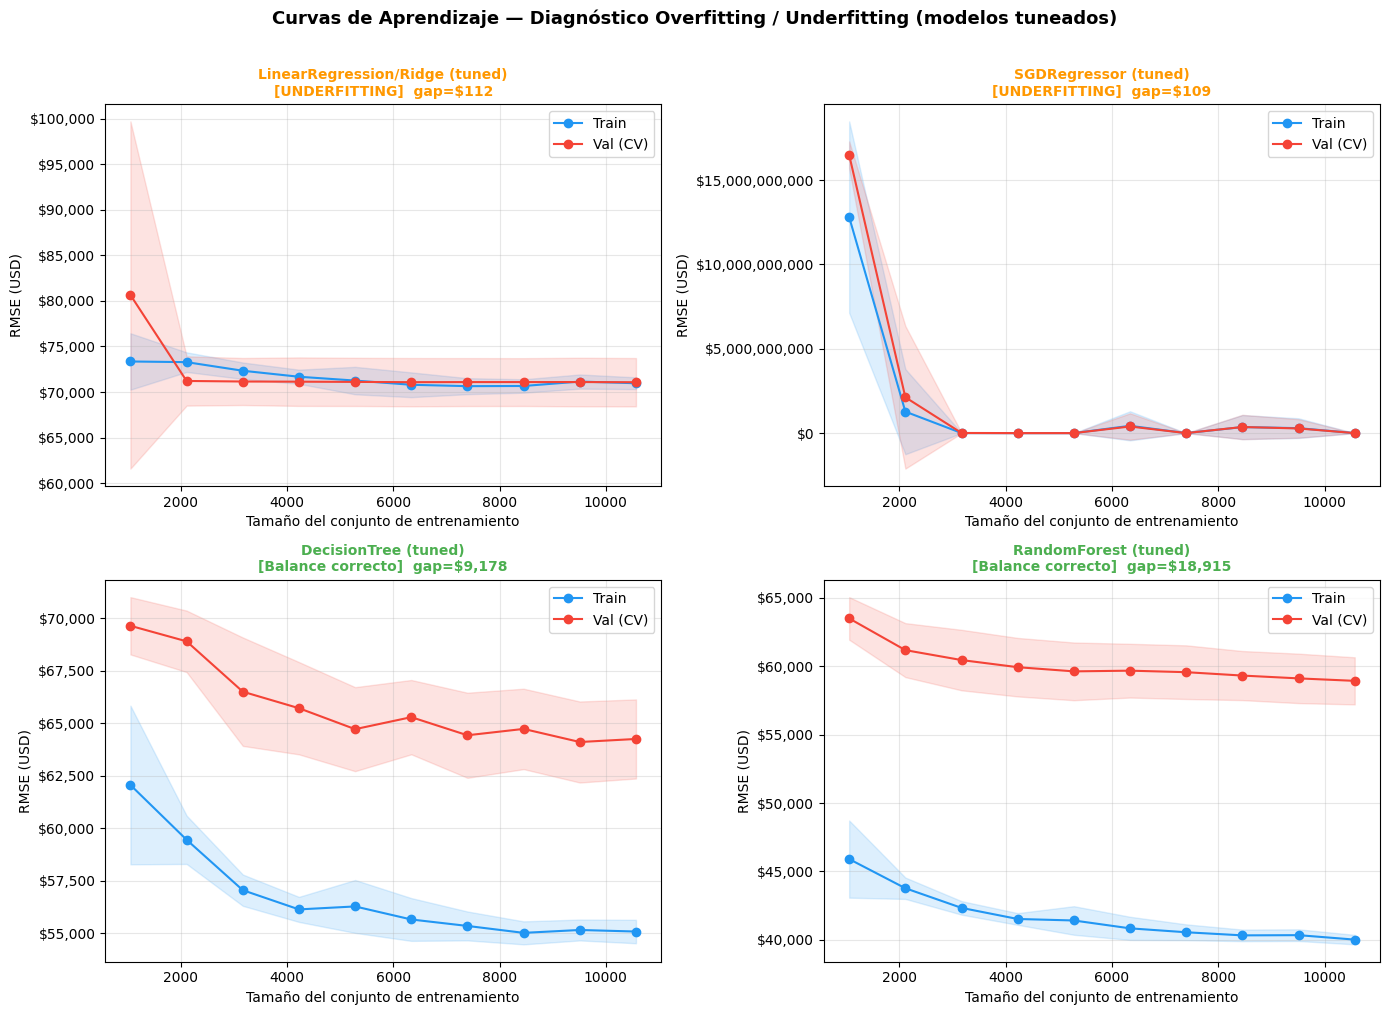

In [5]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(name, model, X, y, ax, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes = np.linspace(0.1, 1.0, 10),
        scoring     = 'neg_root_mean_squared_error',
        cv          = cv,
        n_jobs      = -1,
    )

    train_mean = -train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Train')
    ax.plot(train_sizes, val_mean,   'o-', color='#F44336', label='Val (CV)')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
    ax.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='#F44336')

    gap = val_mean[-1] - train_mean[-1]
    if train_mean[-1] > 70_000:
        diag       = 'UNDERFITTING'
        color_diag = '#FF9800'
    elif gap > 20_000:
        diag       = 'OVERFITTING'
        color_diag = '#F44336'
    else:
        diag       = 'Balance correcto'
        color_diag = '#4CAF50'

    ax.set_title(f'{name}\n[{diag}]  gap=${gap:,.0f}', fontsize=10, fontweight='bold', color=color_diag)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('RMSE (USD)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend()
    ax.grid(True, alpha=0.3)


# Modelos tuneados de los 4 originales del enunciado
modelos_eval = {
    'LinearRegression/Ridge (tuned)' : grid_ridge.best_estimator_,
    'SGDRegressor (tuned)'           : grid_sgd.best_estimator_,
    'DecisionTree (tuned)'           : grid_dt.best_estimator_,
    'RandomForest (tuned)'           : grid_rf.best_estimator_,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, model) in zip(axes.flatten(), modelos_eval.items()):
    plot_learning_curve(name, model, X_train, y_train, ax)

fig.suptitle(
    'Curvas de Aprendizaje — Diagnóstico Overfitting / Underfitting (modelos tuneados)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exp_learning_curves.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 4. Conclusión y Benchmark

### 4.1 Comparación de Modelos

| Modelo | RMSE Train | RMSE Val | R² Val | Diagnóstico |
|--------|-----------|---------|--------|-------------|
| **RandomForest (tuned)** | $39,795 | $58,515 | 0.7365 | ✅ Balance correcto |
| RandomForest (base) | $22,141 | $58,781 | 0.7341 | ⚠️ Overfitting (gap $36,640) |
| DecisionTree (tuned) | $54,854 | $63,983 | 0.6850 | ✅ Balance correcto |
| SGDRegressor (tuned) | $71,003 | $70,239 | 0.6204 | ⚠️ Underfitting (RMSE train > $70,000) |
| LinearRegression (base) | $70,978 | $70,298 | 0.6197 | ⚠️ Underfitting (RMSE train > $70,000) |
| LinearRegression (tuned/Ridge) | $70,978 | $70,298 | 0.6197 | ⚠️ Underfitting (RMSE train > $70,000) |
| SGDRegressor (base) | $162,944 | $73,206 | 0.5876 | ⚠️ Underfitting severo |
| DecisionTree (base) | $0 | $80,426 | 0.5023 | ⚠️ Overfitting total (memorización) |

### 4.2 Análisis de Overfitting / Underfitting

**Modelos con Underfitting:**
- `LinearRegression` (base y Ridge tuned) y `SGDRegressor` (tuned) presentan RMSE Train > $70,000, lo que indica que el modelo es demasiado simple para capturar la complejidad no lineal del precio de las viviendas. La regularización Ridge con `alpha=0.1` no aportó mejora alguna sobre la regresión lineal base — ambos obtienen exactamente el mismo RMSE, lo que confirma que el problema no es la regularización sino la capacidad del modelo.
- `SGDRegressor` (base) es el caso más extremo: RMSE Train de $162,944 por una configuración de `learning_rate` y `eta0` inadecuada, lo que impidió la convergencia.

**Modelos con Overfitting:**
- `DecisionTree` (base) es el caso más claro: RMSE Train = $0 (memorización perfecta) vs RMSE Val = $80,426. Sin restricciones de profundidad, el árbol aprende de memoria cada registro de entrenamiento y no generaliza.
- `RandomForest` (base) también presenta overfitting: gap de $36,640, con RMSE Train de $22,141 vs $58,781 en val. Al no restringir `min_samples_leaf`, los árboles crecen demasiado.

**Modelos balanceados:**
- `DecisionTree` (tuned) con `max_depth=10` y `min_samples_leaf=20` corrige el overfitting total del base, aunque su capacidad predictiva sigue siendo inferior al RandomForest.
- `RandomForest` (tuned) con `min_samples_leaf=5` reduce el gap de $36,640 a $18,720, quedando por debajo del umbral de $20,000, sin sacrificar poder predictivo.

### 4.3 Modelo Ganador — RandomForest (tuned)

**`RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=5)`** es el modelo seleccionado por las siguientes razones:

1. **Menor RMSE Val** ($58,515) — supera a todos los demás modelos en datos no vistos.
2. **Mayor R²** (0.7365) — explica el 73.65% de la varianza del precio, el mejor resultado del benchmark.
3. **Balance correcto** — gap de $18,720 < $20,000, sin overfitting ni underfitting.
4. **MAE Val de $41,343** — el error promedio absoluto es el menor del benchmark, indicando predicciones más consistentes.
5. El fine-tuning fue determinante: `min_samples_leaf=5` corrigió el overfitting del modelo base reduciendo el gap en $17,920 sin pérdida significativa de RMSE Val ($58,515 vs $58,781).

### 4.4 Validación Final en Test Set

In [6]:
# Cargar y transformar test_set con los artefactos de train
test   = pd.read_csv(INTERIM_PATH / 'test_set.csv')
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

num_cols                           = X_test.select_dtypes(include='number').columns
X_test[num_cols]                   = imputer.transform(X_test[num_cols])
X_test['ocean_proximity']          = encoder.transform(X_test[['ocean_proximity']])
X_test['rooms_per_household']      = X_test['total_rooms']    / X_test['households']
X_test['bedrooms_per_room']        = X_test['total_bedrooms'] / X_test['total_rooms']
X_test['population_per_household'] = X_test['population']     / X_test['households']
num_cols_scale                     = [c for c in X_test.columns if c not in ['latitude', 'longitude']]
X_test[num_cols_scale]             = scaler.transform(X_test[num_cols_scale])
X_test                             = X_test.drop(columns=DROP)

# Evaluación final
modelo_final  = grid_rf.best_estimator_
rmse_test     = np.sqrt(mean_squared_error(y_test, modelo_final.predict(X_test)))
mae_test      = mean_absolute_error(y_test, modelo_final.predict(X_test))
r2_test       = r2_score(y_test, modelo_final.predict(X_test))
gap_test      = rmse_test - np.sqrt(mean_squared_error(y_train, modelo_final.predict(X_train)))

print('EVALUACIÓN FINAL — RandomForest (tuned) en Test Set')
print('=' * 52)
print(f'  RMSE Test : ${rmse_test:,.0f}')
print(f'  MAE Test  : ${mae_test:,.0f}')
print(f'  R² Test   : {r2_test:.4f}')
print(f'  Gap       : ${gap_test:,.0f}')
print()
if gap_test > 20_000:
    print('Overfitting detectado en test')
elif np.sqrt(mean_squared_error(y_train, modelo_final.predict(X_train))) > 70_000:
    print('Underfitting detectado')
else:
    print('Modelo balanceado — generaliza correctamente en datos reales')

EVALUACIÓN FINAL — RandomForest (tuned) en Test Set
  RMSE Test : $59,437
  MAE Test  : $41,539
  R² Test   : 0.7361
  Gap       : $19,642

Modelo balanceado — generaliza correctamente en datos reales


> **Interpretación:** Un RMSE cercano al obtenido en validación ($58,515) confirma que el modelo generaliza correctamente a datos completamente nuevos. La diferencia entre RMSE Val y RMSE Test debe ser pequeña — si es mayor a $5,000 podría indicar que el val_set no era suficientemente representativo del test_set.